# 머신러닝으로 동전 개수 세기

지금까지 OpenCV의 규칙 기반 방식으로 동전을 찾았습니다.  
이번 시간에는 **머신러닝** 방식으로 같은 문제를 풀어봅시다.


1. 머신러닝 개념
2. 기존 방식과 비교
2. 특징 추출 및 scikit-learn 모델로 동전 분류
3. 결과 비교, 파라미터 튜닝 실습


# 1. 머신러닝 개념

## 특징(Feature)이란?

컴퓨터가 물체를 구분할 때 사용하는 **숫자 정보**.


동전을 구분할 때 사용할 특징은?

| 특징 이름 | 설명 | 예시 |
|---------|------|------|
| 면적 (area) | 외곽선이 감싸는 픽셀 수 | 3254.5 |
| 원형성 (circularity) | 원에 가까운 정도 (0~1) | 0.82 |
| 종횡비 (aspect ratio) | 가로 / 세로 비율 | 1.05 |
| 볼록도 (solidity) | 실제 면적 / 볼록 껍질 면적 | 0.95 |

## 분류(Classification)란?

특징을 보고 **어떤 종류인지 판단**하는 것입니다.

```
특징값 입력   →   모델   →   결과
[3254, 0.82]  →  SVM   →  동전 / 아님

## SVM

**SVM (Support Vector Machine, 서포트 벡터 머신)**

- 두 그룹을 가장 잘 나누는 경계선을 찾는 모델
- 데이터가 적어도 잘 작동함
- scikit-learn에서 한 줄로 사용 가능

```
동전     ●  ●  ●
         ────────── ← SVM이 찾은 경계선
아님  ■  ■  ■
```


# 2. 기존 방식 vs 머신러닝 방식

### 기존 방식: 규칙 기반

> "원형성이 0.6 이상이면 동전이다"

- 사람이 직접 규칙을 만듦
- 동전 크기나 조명이 달라지면 규칙을 다시 수정해야 함
- 규칙이 많아질수록 코드가 복잡해짐

```
이미지 → 규칙 적용 → 결과
         (사람이 작성)
```

### 머신러닝 방식: 데이터 기반

> "동전 사진을 많이 보여주면, 컴퓨터가 스스로 규칙을 찾는다"

- 사람이 규칙을 만들지 않아도 됨
- 데이터가 많을수록 더 정확해짐
- 새로운 상황에도 잘 적응함

```
이미지 → 특징 추출 → 모델 적용 → 결과
                     (데이터로 학습됨)
```

### 비교 요약

| | 규칙 기반 (OpenCV) | 머신러닝 (scikit-learn) |
|--|------------------|---------------------|
| 규칙 작성 | 사람이 직접 | 컴퓨터가 데이터에서 학습 |
| 데이터 필요 여부 | 불필요 | 필요 |
| 새로운 상황 대응 | 규칙 수정 필요 | 재학습으로 해결 |
| 코드 난이도 | 낮음 | 보통 |

# 3. 실행하기

## 라이브러리 불러오기

- `cv2` : 이미지 처리 (외곽선 검출, 특징 추출)
- `numpy` : 숫자 배열 처리
- `matplotlib` : 이미지 시각화
- `sklearn` : 머신러닝 모델 (SVM, 정확도 측정)
- `joblib` : 학습된 모델 저장/불러오기


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import joblib

print('라이브러리 불러오기 완료!')


라이브러리 불러오기 완료!


## 테스트 이미지 생성

동전(원)과 동전이 아닌 것(사각형, 삼각형)이 섞인 테스트 이미지를 만듭니다.  
머신러닝 모델이 원만 골라낼 수 있는지 확인할 것입니다.

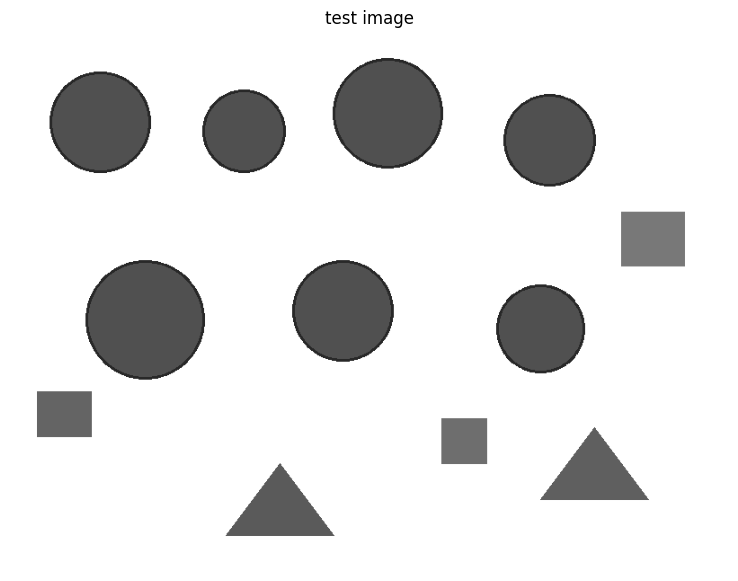

In [2]:
# 흰 배경 이미지 생성 (600x800)
img_bgr = np.ones((600, 800, 3), dtype=np.uint8) * 255

# 동전(원) 7개
coins = [
    (100, 100, 55), (260, 110, 45), (420,  90, 60),
    (600, 120, 50), (150, 320, 65), (370, 310, 55),
    (590, 330, 48),
]
for cx, cy, r in coins:
    cv2.circle(img_bgr, (cx, cy), r, (80, 80, 80), -1)
    cv2.circle(img_bgr, (cx, cy), r, (40, 40, 40),  2)

# 노이즈(사각형 3개, 삼각형 2개)
# cv2.rectangle(이미지, 왼쪽위좌표, 오른쪽아래좌표, 색상, 두께)
# 두께 -1 : 꽉 채워서 그림
cv2.rectangle(img_bgr, (680, 200), (750, 260), (120, 120, 120), -1)
cv2.rectangle(img_bgr, ( 30, 400), ( 90, 450), (100, 100, 100), -1)
cv2.rectangle(img_bgr, (480, 430), (530, 480), (110, 110, 110), -1)

# 삼각형 꼭짓점 좌표 정의
# np.array([꼭짓점1, 꼭짓점2, 꼭짓점3], 데이터타입)
# np.int32 : 정수형 좌표값
tri1 = np.array([[300, 480], [360, 560], [240, 560]], np.int32)
tri2 = np.array([[650, 440], [710, 520], [590, 520]], np.int32)

# 삼각형 2개 채워서 그리기 (노이즈 역할)
# cv2.fillPoly(이미지, [꼭짓점배열], 색상)
# fillPoly : 다각형 내부를 색상으로 꽉 채움
cv2.fillPoly(img_bgr, [tri1], (90, 90, 90))
cv2.fillPoly(img_bgr, [tri2], (95, 95, 95))

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title('test image')
plt.axis('off')
plt.show()


## 전처리 (그레이스케일 → 이진화 → 모폴로지)

기존 방식과 동일하게 전처리


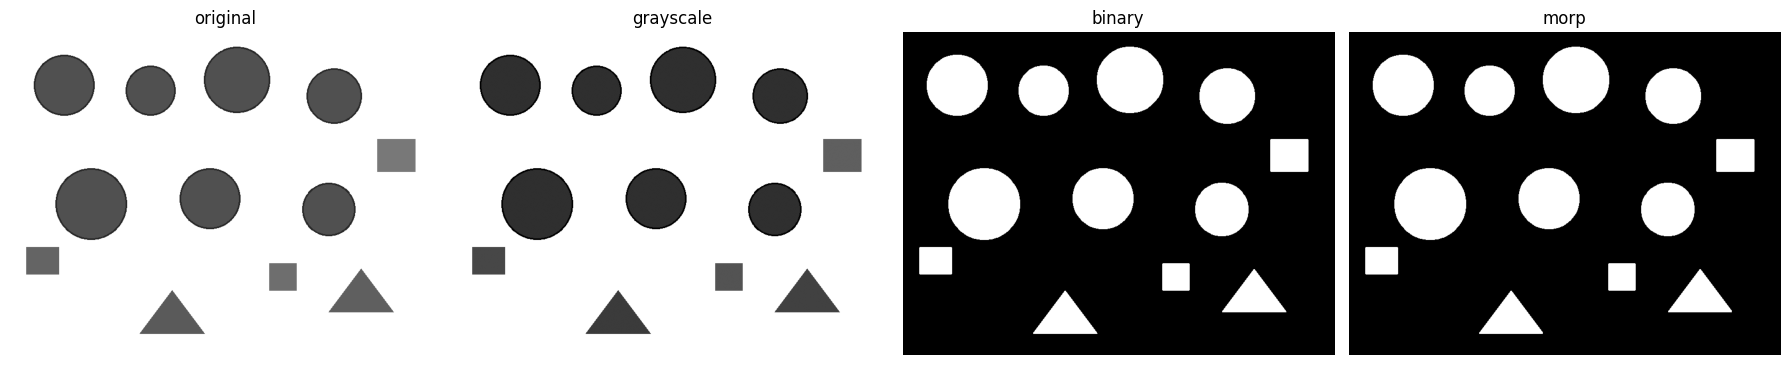

In [3]:
# 그레이스케일 변환
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 가우시안 필터 (Noise 제거)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 이진화 (Otsu)
_, binary = cv2.threshold(blur, 0, 255,
                           cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 모폴로지
kernel = np.ones((3, 3), np.uint8)
morph  = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

# 시각화
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, img, title in zip(
    axes,
    [cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), gray, binary, morph],
    ['original', 'grayscale', 'binary', 'morp']
):
    cmap = 'gray' if img.ndim == 2 else None
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 특징 추출

각 외곽선에서 **4가지 특징값**을 숫자로 뽑아냅니다.  
이 특징값(숫자)들이 모델의 입력이 됩니다.

| 특징 | 공식 | 동전이면 |
|------|------|--------|
| 면적 | contourArea() | 크다 |
| 원형성 | 4π × 면적 / 둘레² | 1에 가깝다 |
| 종횡비 | 가로 / 세로 | 1에 가깝다 |
| 볼록도 | 면적 / 볼록껍질 면적 | 1에 가깝다 |

### cv2.convexHull(points)

외곽선을 감싸는 볼록 껍질(Convex Hull)을 구합니다.  
볼록도 계산에 사용됩니다.

| 파라미터 | 설명 |
|---------|------|
| points | 외곽선 좌표 배열 |
| 반환값 | 볼록 껍질 좌표 배열 |


In [4]:
def extract_features(contour):
    """외곽선 하나에서 4가지 특징값 추출"""

    # 1) 면적
    # cv2.contourArea(외곽선) : 외곽선이 감싸는 영역의 픽셀 수 반환
    area = cv2.contourArea(contour)

    # 2) 원형성: 1에 가까울수록 원
    # cv2.arcLength(외곽선, 닫힌도형여부) : 외곽선의 둘레 길이 반환
    # True = 닫힌 도형으로 계산
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0: # 둘레가 0이면 나눗셈 불가 → None 반환 후 건너뜀
        return None
    circularity = 4 * np.pi * area / (perimeter ** 2) # 원형성 공식: 4π × 면적 / 둘레²
                                                      # 완전한 원 = 1.0 / 울퉁불퉁할수록 0에 가까워짐

    # 3) 종횡비: 가로/세로, 1에 가까울수록 원
    # cv2.boundingRect(외곽선) : 외곽선을 감싸는 최소 사각형 반환
    # 반환값 → x: 왼쪽위 x좌표, y: 왼쪽위 y좌표, w: 너비, h: 높이

    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / h if h != 0 else 0 # h가 0이면 나눗셈 불가 → 0으로 처리

    # 4) 볼록도: 실제 면적 / Convex Hull(볼록 껍질) 면적
    # cv2.convexHull(외곽선) : 외곽선을 감싸는 볼록 껍질 좌표 반환
    # 오목한 부분 없이 바깥으로만 이루어진 껍질
    hull      = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull) # 볼록 껍질의 면적 계산
    # hull_area가 0이면 나눗셈 불가 → 0으로 처리
    # 완전히 볼록한 도형 = 1.0 / 오목한 부분이 많을수록 0에 가까워짐
    solidity  = area / hull_area if hull_area != 0 else 0

    return [area, circularity, aspect_ratio, solidity]


# 외곽선 검출
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)

# 특징 추출
features_list  = []
contours_valid = []

for contour in contours:
    if cv2.contourArea(contour) < 300:
        continue
    feat = extract_features(contour)
    if feat is None:
        continue
    features_list.append(feat)
    contours_valid.append(contour)

# 리스트를 numpy 배열로 변환: scikit-learn 모델 입력에 필요
features_array = np.array(features_list)

# 추출 결과 출력
print(f'검출된 외곽선 수: {len(contours_valid)}개')
print()
print(f'{"번호":>4}  {"면적":>8}  {"원형성":>8}  {"종횡비":>8}  {"볼록도":>8}')
print('-' * 50)
for i, feat in enumerate(features_list):
    print(f'  {i+1:>2}  {feat[0]:>8.1f}  {feat[1]:>8.3f}  '
          f'{feat[2]:>8.3f}  {feat[3]:>8.3f}')


검출된 외곽선 수: 12개

  번호        면적       원형성       종횡비       볼록도
--------------------------------------------------
   1    4796.5     0.572     1.475     0.988
   2    4796.5     0.572     1.475     0.988
   3    2498.0     0.803     1.000     1.000
   4    2998.0     0.795     1.196     1.000
   5    7642.0     0.901     1.000     0.991
   6    9946.0     0.898     1.000     0.991
   7   13796.0     0.900     1.000     0.992
   8    4198.0     0.795     1.164     1.000
   9    8238.0     0.908     1.000     0.992
  10    6710.0     0.908     1.000     0.992
  11    9946.0     0.898     1.000     0.991
  12   11770.0     0.908     1.000     0.993


## 학습 데이터 준비

모델에게 '이것은 동전이다 / 아니다' 를 알려주는 **정답 레이블**을 만듭니다.

- `1` = 동전
- `0` = 동전 아님 (사각형, 삼각형 등)

> 각 번호가 동전인지 확인한 후, 아래 labels 리스트를 직접 채워보세요.

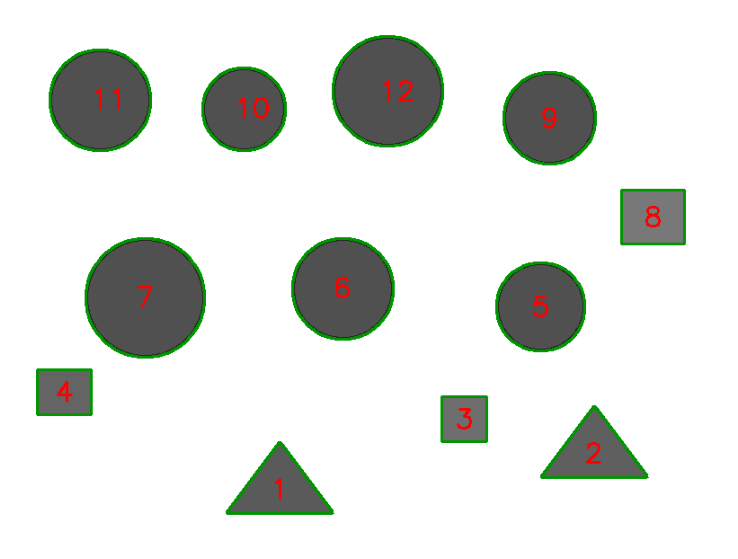

In [5]:
# 외곽선에 번호 표시 — 직접 눈으로 확인하기
result_label = img_bgr.copy()

for i, contour in enumerate(contours_valid):
    M = cv2.moments(contour)
    if M['m00'] == 0:
        continue
    cx = int(M['m10'] / M['m00'])   # x 중심 좌표
    cy = int(M['m01'] / M['m00'])   # y 중심 좌표

    # 외곽선 테두리 그리기
    cv2.drawContours(result_label, [contour], -1, (0, 150, 0), 2)

    # 중심에 번호 표시
    cv2.putText(result_label, str(i + 1), (cx - 10, cy + 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(result_label, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [6]:
# 위 출력 결과를 보고 동전(원)이면 1, 아니면 0 으로 입력하세요
# 예) 외곽선이 12개라면 → labels = [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1]
labels = [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1]   # ← 여기에 직접 채워보세요!
labels = np.array(labels)

## 모델 학습 + 저장

SVM 모델에 특징값과 레이블을 넣어 학습시킵니다.

### StandardScaler
특징값의 크기가 제각각이면 모델이 혼란스러워집니다.  
예) 면적: 3000, 원형성: 0.8 → 면적이 너무 크면 원형성이 무시될 수 있음  
StandardScaler는 모든 특징값을 비슷한 범위로 맞춰줍니다.

### SVC(kernel='rbf')
RBF 커널을 사용하는 SVM 분류 모델입니다.  
직선이 아닌 곡선 경계선을 그릴 수 있어 더 유연하게 분류합니다.


In [7]:
# 특징값 정규화
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features_array)

# SVM 모델 학습
# kernel='rbf' : 곡선 경계선 사용
# C=1.0        : 경계선 엄격함 — 클수록 엄격, 작을수록 유연
model = SVC(kernel='rbf', C=1.0, probability=True)
model.fit(X_scaled, labels)
print('모델 학습 완료!')

# 학습 정확도 확인
train_preds    = model.predict(X_scaled)
train_accuracy = accuracy_score(labels, train_preds)
print(f'학습 정확도: {train_accuracy * 100:.1f}%')

# 모델 저장
joblib.dump(model,  'coin_model.pkl')
joblib.dump(scaler, 'coin_scaler.pkl')
print('모델 저장 완료! (coin_model.pkl, coin_scaler.pkl)')


모델 학습 완료!
학습 정확도: 100.0%
모델 저장 완료! (coin_model.pkl, coin_scaler.pkl)


## 저장된 모델 불러오기 + 추론

저장된 모델을 불러와서 동전인지 판별합니다.

### model.predict(X)

| 파라미터 | 설명 |
|---------|------|
| X | 정규화된 특징값 배열 |
| 반환값 | 예측 레이블 배열 — 1: 동전, 0: 동전 아님 |

### model.predict_proba(X)

| 파라미터 | 설명 |
|---------|------|
| X | 정규화된 특징값 배열 |
| 반환값 | 각 클래스일 확률 — [[0.2, 0.8], ...] (0일 확률, 1일 확률) |


In [8]:
# 저장된 모델 불러오기
loaded_model  = joblib.load('coin_model.pkl')
loaded_scaler = joblib.load('coin_scaler.pkl')
print('모델 불러오기 완료!')

# 추론
X_scaled_new  = loaded_scaler.transform(features_array)
predictions   = loaded_model.predict(X_scaled_new)
probabilities = loaded_model.predict_proba(X_scaled_new)

# 결과 출력
print()
print(f'{"번호":>4}  {"원형성":>8}  {"동전 확률":>10}  {"판정":>8}')
print('-' * 42)

ml_coin_count = 0
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    verdict    = '동전' if pred == 1 else '아님'
    coin_prob  = prob[1] * 100
    circ       = features_list[i][1]
    if pred == 1:
        ml_coin_count += 1
    print(f'  {i+1:>2}  {circ:>8.3f}  {coin_prob:>9.1f}%  {verdict}')

print()
print(f'머신러닝 모델 판정 동전 개수: {ml_coin_count}개')


모델 불러오기 완료!

  번호       원형성       동전 확률        판정
------------------------------------------
   1     0.572       10.7%  아님
   2     0.572       10.7%  아님
   3     0.803       10.7%  아님
   4     0.795       10.1%  아님
   5     0.901       88.8%  동전
   6     0.898       91.4%  동전
   7     0.900       88.8%  동전
   8     0.795       10.7%  아님
   9     0.908       89.7%  동전
  10     0.908       85.8%  동전
  11     0.898       91.4%  동전
  12     0.908       91.0%  동전

머신러닝 모델 판정 동전 개수: 7개


## 결과 시각화

ML 모델이 동전으로 판정한 외곽선을 이미지에 표시합니다.

- 초록색 : 동전으로 판정
- 빨간색 : 동전 아님으로 판정


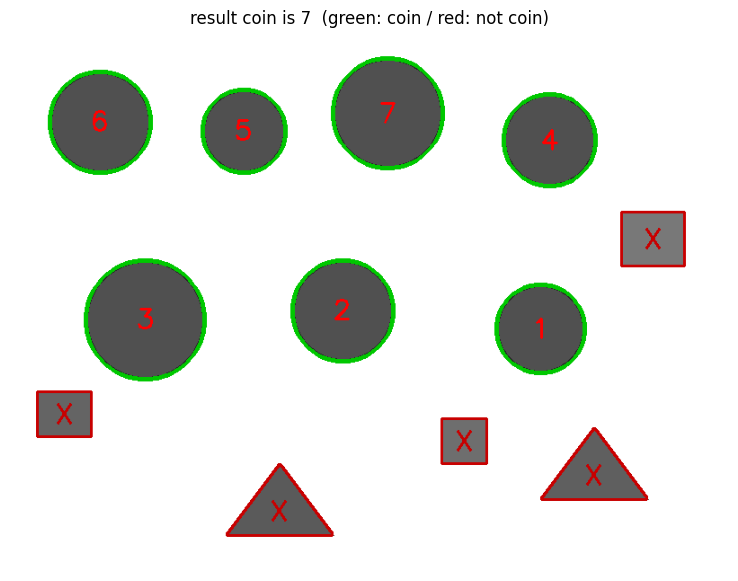

In [9]:
result_ml = img_bgr.copy()
coin_num  = 0

for contour, pred in zip(contours_valid, predictions):
    M = cv2.moments(contour)
    if M['m00'] == 0:
        continue
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])

    if pred == 1:   # 동전으로 판정
        coin_num += 1
        cv2.drawContours(result_ml, [contour], -1, (0, 200, 0), 3)
        cv2.putText(result_ml, str(coin_num), (cx - 10, cy + 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    else:           # 동전 아님으로 판정
        cv2.drawContours(result_ml, [contour], -1, (0, 0, 200), 2)
        cv2.putText(result_ml, 'X', (cx - 10, cy + 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 200), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(result_ml, cv2.COLOR_BGR2RGB))
plt.title(f'result coin is {ml_coin_count}  (green: coin / red: not coin)')
plt.axis('off')
plt.show()


## 기존 방식 vs 머신러닝 방식 비교

두 방식의 결과를 나란히 비교해보세요.


In [10]:
# 여기에 기존 코드를 넣어 비교해보세요.

## 파라미터 튜닝 실습

아래 값들을 바꿔가면서 결과가 어떻게 달라지는지 확인해보세요.

| 파라미터 | 기본값 | 설명 |
|---------|--------|------|
| C | 1.0 | 클수록 엄격하게 분류. 너무 크면 과적합 |
| kernel | rbf | linear: 직선, rbf: 곡선, poly: 다항식 |
| min_area | 300 | 이 픽셀보다 작은 외곽선은 무시 |


parameter: C=1.0, kernel=rbf, min_area=300
accuracy : 100.0%
coin: 7


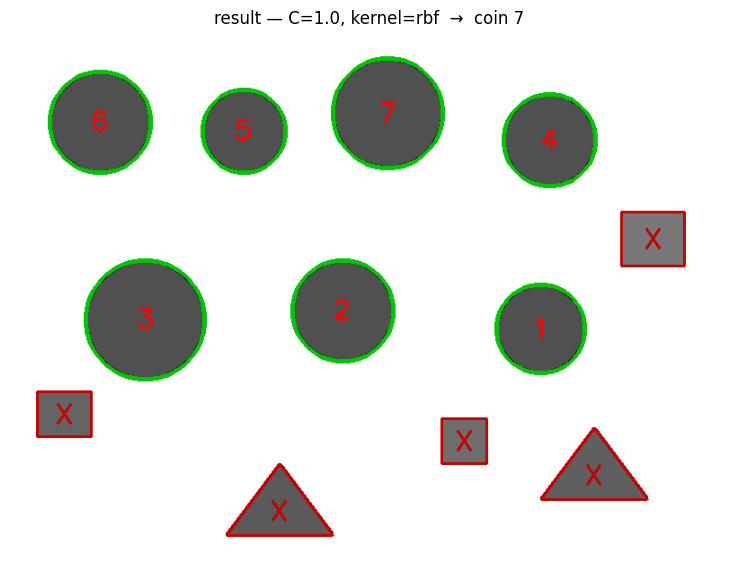

In [11]:
# 여기서 값을 바꿔보세요!
C_VALUE  = 1.0      # 0.1 / 1.0 / 10.0
KERNEL   = 'rbf'    # 'rbf' / 'linear' / 'poly'
MIN_AREA = 300      # 100 / 300 / 500

# 재학습
new_model = SVC(kernel=KERNEL, C=C_VALUE, probability=True)
new_model.fit(X_scaled, labels)
new_preds    = new_model.predict(X_scaled)
new_accuracy = accuracy_score(labels, new_preds)
coin_num_new = int(np.sum(new_preds == 1))

print(f'parameter: C={C_VALUE}, kernel={KERNEL}, min_area={MIN_AREA}')
print(f'accuracy : {new_accuracy * 100:.1f}%')
print(f'coin: {coin_num_new}')

# 결과 시각화
result_tuned = img_bgr.copy()
coin_num_t   = 0

for contour, pred in zip(contours_valid, new_preds):
    M = cv2.moments(contour)
    if M['m00'] == 0:
        continue
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    if pred == 1:
        coin_num_t += 1
        cv2.drawContours(result_tuned, [contour], -1, (0, 200, 0), 3)
        cv2.putText(result_tuned, str(coin_num_t), (cx-10, cy+10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    else:
        cv2.drawContours(result_tuned, [contour], -1, (0, 0, 200), 2)
        cv2.putText(result_tuned, 'X', (cx-10, cy+10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 200), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(result_tuned, cv2.COLOR_BGR2RGB))
plt.title(f'result — C={C_VALUE}, kernel={KERNEL}  →  coin {coin_num_t}')
plt.axis('off')
plt.show()


### 생각해봅시다.

1. 기존 방식과 머신러닝 방식 중 어느 쪽이 더 정확했나요?
2. `C` 값을 크게 하면 어떤 일이 일어났나요?
3. 특징을 더 추가한다면 무엇을 추가하면 좋을까요?
4. 실제 동전 사진으로 테스트하면 결과가 어떻게 달라질까요?
